# 01 — Documentação das Bases
**Grupo 1 | Séries Temporais**

Este notebook documenta a base de dados utilizada pelo Grupo 1, descreve as variáveis disponíveis, apresenta estatísticas descritivas e verifica a integridade dos dados.

## 1. Identificação da Base

| Item | Descrição |
|------|----------|
| **Base** | Bitcoin (BTC/USD) — Preço diário |
| **Arquivo** | `bases/grupo1/bitcoin.xlsx` |
| **Fonte** | CoinMarketCap |
| **Período** | 22/08/2018 a 11/09/2026 |
| **Frequência** | Diária |
| **Variável-alvo** | `priceClose` — Preço de fechamento do Bitcoin em USD |
| **Unidade** | Dólares americanos (USD) |

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Localiza a raiz do projeto sem depender do diretório atual do kernel.
CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = DATA_DIR
BASE_PATH = PROJECT_ROOT / 'bases' / 'grupo1' / 'bitcoin.xlsx'

# Estilo visual
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
    'font.size': 11
})

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70

## 2. Carregamento e Preparação Inicial

In [2]:
# Carregamento
df_raw = pd.read_excel(BASE_PATH)

# Converter timestamps Unix (ms) para datetime
for col in ['timeOpen', 'timeClose', 'timeHigh', 'timeLow']:
    df_raw[col] = pd.to_datetime(df_raw[col], unit='ms')

# Ordenar por data e usar timeOpen como índice temporal
df_raw = df_raw.rename(columns={'timeOpen': 'date'})
df_raw['date'] = df_raw['date'].dt.normalize()  # normaliza para meia-noite
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f'Shape: {df_raw.shape}')
print(f'Período: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'Total de dias: {(df_raw["date"].max() - df_raw["date"].min()).days + 1}')
print(f'Total de registros: {len(df_raw)}')
df_raw.head()

Shape: (2920, 9)
Período: 2018-08-22 → 2026-09-11
Total de dias: 2943
Total de registros: 2920


,date,timeClose,timeHigh,timeLow,priceOpen,priceHigh,priceLow,priceClose,volume
0,2018-08-22,2018-08-23 11:59:59.999,2018-08-22 14:04:02,2018-08-23 10:19:00,6486.25,6816.79,6310.11,6376.71,4.668110e+09
1,2018-08-23,2018-08-24 11:59:59.999,2018-08-24 10:14:00,2018-08-23 12:04:00,6371.34,6546.54,6371.34,6534.88,3.426180e+09
2,2018-08-24,2018-08-25 11:59:59.999,2018-08-25 11:59:00,2018-08-24 13:34:00,6551.52,6719.96,6498.64,6719.96,4.097820e+09
3,2018-08-25,2018-08-26 11:59:59.999,2018-08-25 14:39:00,2018-08-25 19:49:00,6719.95,6789.63,6700.96,6763.19,3.312600e+09
4,2018-08-26,2018-08-27 11:59:59.999,2018-08-26 12:44:00,2018-08-26 18:14:01,6754.64,6774.75,6620.75,6707.26,3.295500e+09


## 3. Dicionário de Variáveis

In [3]:
dicionario = pd.DataFrame({
    'Variável': ['date', 'timeClose', 'timeHigh', 'timeLow',
                 'priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume'],
    'Tipo': ['datetime', 'datetime', 'datetime', 'datetime',
             'float64', 'float64', 'float64', 'float64', 'float64'],
    'Descrição': [
        'Data de abertura do candle diário (índice temporal)',
        'Data/hora de fechamento do candle diário',
        'Data/hora do preço máximo no dia',
        'Data/hora do preço mínimo no dia',
        'Preço de abertura do Bitcoin em USD',
        'Preço máximo atingido no dia em USD',
        'Preço mínimo atingido no dia em USD',
        'Preço de fechamento do Bitcoin em USD  ← VARIÁVEL-ALVO',
        'Volume financeiro negociado no dia em USD'
    ],
    'Papel': [
        'Índice temporal',
        'Auxiliar (descartada na modelagem)',
        'Auxiliar (descartada na modelagem)',
        'Auxiliar (descartada na modelagem)',
        'Variável externa (disponível no dia)',
        'Variável externa (disponível no dia)',
        'Variável externa (disponível no dia)',
        '🎯 Alvo (prever t+1)',
        'Variável externa (disponível no dia)'
    ]
})
print(dicionario.to_string(index=False))

  Variável     Tipo                                              Descrição                                Papel
      date datetime    Data de abertura do candle diário (índice temporal)                      Índice temporal
 timeClose datetime               Data/hora de fechamento do candle diário   Auxiliar (descartada na modelagem)
  timeHigh datetime                       Data/hora do preço máximo no dia   Auxiliar (descartada na modelagem)
   timeLow datetime                       Data/hora do preço mínimo no dia   Auxiliar (descartada na modelagem)
 priceOpen  float64                    Preço de abertura do Bitcoin em USD Variável externa (disponível no dia)
 priceHigh  float64                    Preço máximo atingido no dia em USD Variável externa (disponível no dia)
  priceLow  float64                    Preço mínimo atingido no dia em USD Variável externa (disponível no dia)
priceClose  float64 Preço de fechamento do Bitcoin em USD  ← VARIÁVEL-ALVO                  🎯 Alvo (prev

## 4. Disponibilidade das Variáveis Externas

Para previsão do preço de fechamento do dia seguinte (`priceClose` de amanhã), as variáveis devem estar disponíveis **na data de origem da previsão** (hoje).

| Variável | Disponibilidade | Justificativa |
|----------|----------------|---------------|
| `priceOpen` | ✅ Disponível (com lag) | Preço de abertura do dia *atual* está disponível para prever o fechamento do dia *seguinte* via lag-1 |
| `priceHigh` | ✅ Disponível (com lag) | Preço máximo do dia *atual* está disponível via lag-1 |
| `priceLow` | ✅ Disponível (com lag) | Preço mínimo do dia *atual* está disponível via lag-1 |
| `volume` | ✅ Disponível (com lag) | Volume do dia *atual* está disponível via lag-1 |
| `priceClose` (futuro) | ❌ Indisponível | Seria o próprio alvo — causaria vazamento de dados |

> **Estratégia adotada:** Todos os preços OHLC e volume serão usados apenas com defasagem (lag ≥ 1), garantindo que nenhuma informação futura seja utilizada.

## 5. Estatísticas Descritivas

In [4]:
cols_numericas = ['priceOpen', 'priceHigh', 'priceLow', 'priceClose', 'volume']
desc = df_raw[cols_numericas].describe().T
desc.columns = ['N', 'Média', 'Desvio Padrão', 'Mín', 'Q1', 'Mediana', 'Q3', 'Máx']
desc['N'] = desc['N'].astype(int)
print('=== Estatísticas Descritivas ===')
print(desc.round(2).to_string())

=== Estatísticas Descritivas ===
               N         Média  Desvio Padrão           Mín            Q1       Mediana            Q3           Máx
priceOpen   2920  4.260601e+04   3.253687e+04  3.236270e+03  1.128361e+04  3.544349e+04  6.483984e+04  1.247521e+05
priceHigh   2920  4.342065e+04   3.304854e+04  3.275380e+03  1.152704e+04  3.643487e+04  6.599898e+04  1.261981e+05
priceLow    2920  4.174186e+04   3.198317e+04  3.191300e+03  1.100216e+04  3.388040e+04  6.365737e+04  1.231961e+05
priceClose  2920  4.262638e+04   3.253592e+04  3.236760e+03  1.131568e+04  3.546960e+04  6.487266e+04  1.247525e+05
volume      2920  3.258845e+10   2.136542e+10  3.064030e+09  1.811972e+10  2.861792e+10  4.164237e+10  3.509679e+11


In [5]:
# Registros por ano
df_raw['year'] = df_raw['date'].dt.year
registros_ano = df_raw.groupby('year').agg(
    registros=('priceClose', 'count'),
    preco_medio=('priceClose', 'mean'),
    preco_min=('priceClose', 'min'),
    preco_max=('priceClose', 'max'),
    vol_medio=('volume', 'mean')
).round(2)
print('=== Resumo por Ano ===')
print(registros_ano.to_string())

=== Resumo por Ano ===
      registros  preco_medio  preco_min  preco_max     vol_medio
year                                                            
2018        132      5642.99    3236.76    7361.66  4.666307e+09
2019        365      7395.25    3399.47   13016.23  1.673049e+10
2020        366     11116.38    4970.79   29001.72  3.302327e+10
2021        365     47436.93   29374.15   67566.83  4.715574e+10
2022        365     28197.88   15787.28   47686.81  2.996970e+10
2023        342     28372.94   16625.08   43997.90  1.810851e+10
2024        366     65963.58   39507.37  106140.60  3.743545e+10
2025        365    101641.92   76271.95  124752.53  5.301822e+10
2026        254     72457.02   58558.86   96929.33  3.524509e+10


## 6. Verificação de Qualidade dos Dados

In [6]:
print('=== 6.1 Valores Ausentes ===')
nulos = df_raw[cols_numericas].isnull().sum()
print(nulos)
print(f'\nTotal de nulos: {nulos.sum()}')

=== 6.1 Valores Ausentes ===
priceOpen     0
priceHigh     0
priceLow      0
priceClose    0
volume        0
dtype: int64

Total de nulos: 0


In [7]:
print('=== 6.2 Duplicatas ===')
dup_total = df_raw.duplicated().sum()
dup_data  = df_raw['date'].duplicated().sum()
print(f'Linhas completamente duplicadas: {dup_total}')
print(f'Datas duplicadas: {dup_data}')

=== 6.2 Duplicatas ===
Linhas completamente duplicadas: 0
Datas duplicadas: 0


In [8]:
print('=== 6.3 Irregularidades Temporais (lacunas) ===')
df_raw['day_diff'] = df_raw['date'].diff().dt.days
gaps = df_raw[df_raw['day_diff'] > 1][['date', 'day_diff']].copy()
print(f'Total de lacunas (>1 dia): {len(gaps)}')
if len(gaps) > 0:
    print(gaps.to_string(index=False))
    print('\n→ Lacunas serão tratadas por interpolação linear no notebook de limpeza.')

=== 6.3 Irregularidades Temporais (lacunas) ===
Total de lacunas (>1 dia): 5
      date  day_diff
2023-09-22       5.0
2023-09-24       2.0
2023-11-04       3.0
2023-11-14       9.0
2023-12-09       9.0

→ Lacunas serão tratadas por interpolação linear no notebook de limpeza.


In [9]:
print('=== 6.4 Valores Atípicos (método IQR) ===')
for col in ['priceClose', 'volume']:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_raw[(df_raw[col] < lower) | (df_raw[col] > upper)]
    print(f'{col}: {len(outliers)} outliers  |  Limites: [{lower:.2f}, {upper:.2f}]')
print('\n→ Bitcoin apresenta alta volatilidade intrínseca; outliers não serão removidos,')
print('  mas serão monitorados. A série será analisada em escala original e log.')

=== 6.4 Valores Atípicos (método IQR) ===
priceClose: 0 outliers  |  Limites: [-69019.79, 145208.13]
volume: 106 outliers  |  Limites: [-17164258732.25, 76926341372.63]

→ Bitcoin apresenta alta volatilidade intrínseca; outliers não serão removidos,
  mas serão monitorados. A série será analisada em escala original e log.


## 7. Visualizações da Série-Alvo

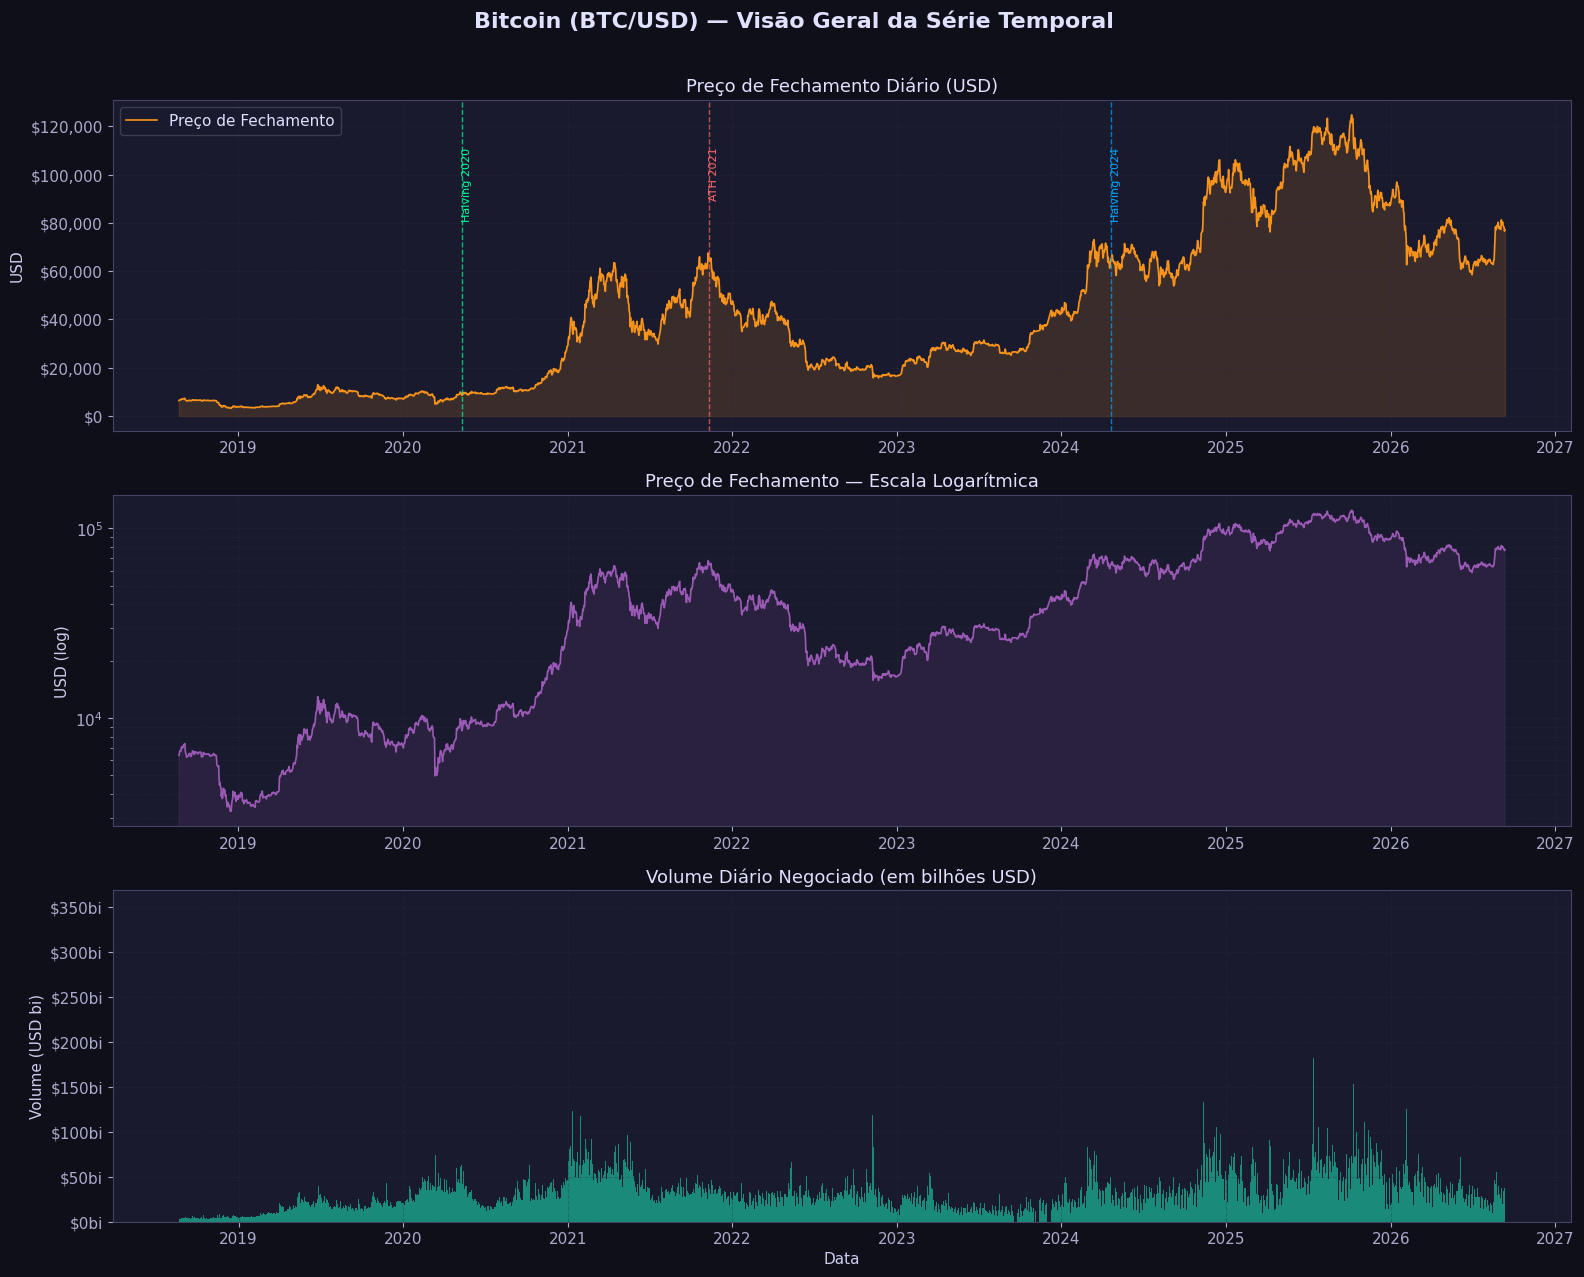

Gráfico salvo: plot_01_serie_alvo.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor='#0f0f1a')
fig.suptitle('Bitcoin (BTC/USD) — Visão Geral da Série Temporal', 
             fontsize=16, fontweight='bold', color='#e0e0ff', y=0.98)

# ── Subplot 1: priceClose ao longo do tempo
ax1 = axes[0]
ax1.plot(df_raw['date'], df_raw['priceClose'], color='#f7931a', linewidth=1.2, label='Preço de Fechamento')
ax1.fill_between(df_raw['date'], df_raw['priceClose'], alpha=0.15, color='#f7931a')
ax1.set_title('Preço de Fechamento Diário (USD)', color='#e0e0ff', fontsize=13)
ax1.set_ylabel('USD', color='#ccccee')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(True, alpha=0.3)
ax1.legend(framealpha=0.2)

# Marcadores de eventos relevantes
eventos = {
    '2020-05-11': ('Halving 2020', '#00ff99'),
    '2024-04-19': ('Halving 2024', '#00aaff'),
    '2021-11-10': ('ATH 2021', '#ff6b6b'),
}
for data_str, (label, cor) in eventos.items():
    dt = pd.Timestamp(data_str)
    ax1.axvline(dt, color=cor, linestyle='--', alpha=0.7, linewidth=1)
    ax1.text(dt, ax1.get_ylim()[1]*0.85, label, color=cor, fontsize=8, rotation=90, va='top')

# ── Subplot 2: Escala logarítmica
ax2 = axes[1]
ax2.semilogy(df_raw['date'], df_raw['priceClose'], color='#9b59b6', linewidth=1.2)
ax2.fill_between(df_raw['date'], df_raw['priceClose'], alpha=0.12, color='#9b59b6')
ax2.set_title('Preço de Fechamento — Escala Logarítmica', color='#e0e0ff', fontsize=13)
ax2.set_ylabel('USD (log)', color='#ccccee')
ax2.grid(True, which='both', alpha=0.3)

# ── Subplot 3: Volume diário
ax3 = axes[2]
ax3.bar(df_raw['date'], df_raw['volume'] / 1e9, color='#1abc9c', alpha=0.7, width=1)
ax3.set_title('Volume Diário Negociado (em bilhões USD)', color='#e0e0ff', fontsize=13)
ax3.set_ylabel('Volume (USD bi)', color='#ccccee')
ax3.set_xlabel('Data', color='#ccccee')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}bi'))
ax3.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_DIR / 'plot_01_serie_alvo.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Gráfico salvo: plot_01_serie_alvo.png')

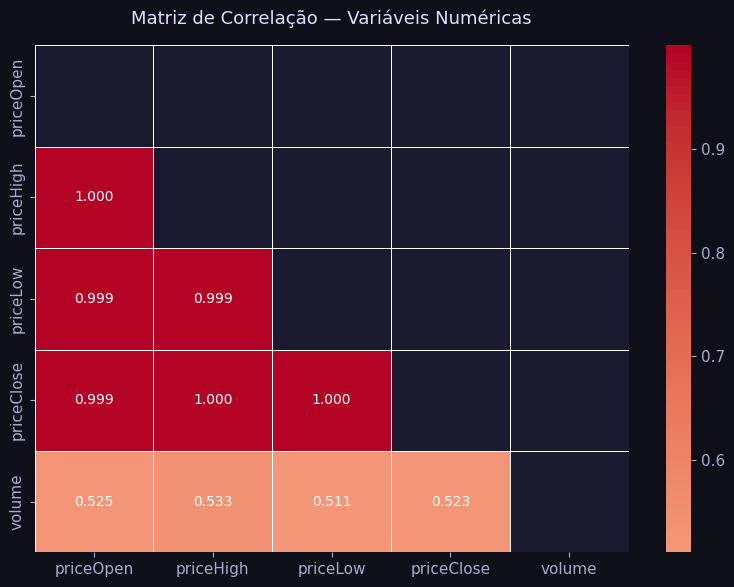

Gráfico salvo: plot_02_correlacao.png


In [11]:
# Correlação entre variáveis numéricas
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='#0f0f1a')
corr = df_raw[cols_numericas].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.5,
    annot_kws={'size': 10, 'color': 'white'}
)
ax.set_title('Matriz de Correlação — Variáveis Numéricas', 
             color='#e0e0ff', fontsize=13, pad=15)
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='#aaaacc')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_02_correlacao.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Gráfico salvo: plot_02_correlacao.png')

## 8. Divisão Treino / Teste

A divisão segue o protocolo definido: **70% treino, 30% teste**, respeitando a ordem temporal.

=== Divisão Treino / Teste ===
Total de observações : 2920
Treino (70%)         : 2043 observações
Teste  (30%)         : 877 observações
Data de corte        : 2024-04-18
Período de treino    : 2018-08-22 → 2024-04-17
Período de teste     : 2024-04-18 → 2026-09-11


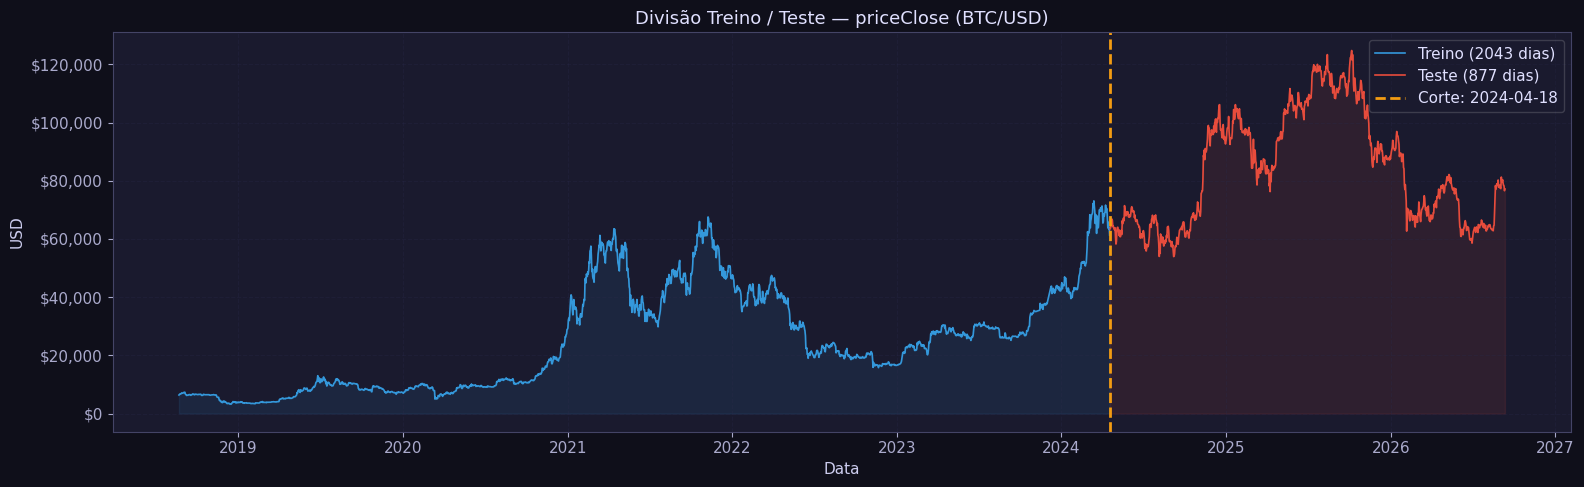

In [12]:
n = len(df_raw)
n_train = int(n * TRAIN_RATIO)
n_test  = n - n_train

data_corte = df_raw.iloc[n_train]['date']

print('=== Divisão Treino / Teste ===')
print(f'Total de observações : {n}')
print(f'Treino (70%)         : {n_train} observações')
print(f'Teste  (30%)         : {n_test} observações')
print(f'Data de corte        : {data_corte.date()}')
print(f'Período de treino    : {df_raw["date"].min().date()} → {df_raw.iloc[n_train-1]["date"].date()}')
print(f'Período de teste     : {data_corte.date()} → {df_raw["date"].max().date()}')

# Visualização da divisão
fig, ax = plt.subplots(figsize=(16, 5), facecolor='#0f0f1a')
train_df = df_raw.iloc[:n_train]
test_df  = df_raw.iloc[n_train:]
ax.plot(train_df['date'], train_df['priceClose'], color='#3498db', linewidth=1.2, label=f'Treino ({n_train} dias)')
ax.plot(test_df['date'],  test_df['priceClose'],  color='#e74c3c', linewidth=1.2, label=f'Teste ({n_test} dias)')
ax.axvline(data_corte, color='#f39c12', linestyle='--', linewidth=2, label=f'Corte: {data_corte.date()}')
ax.fill_between(train_df['date'], train_df['priceClose'], alpha=0.1, color='#3498db')
ax.fill_between(test_df['date'],  test_df['priceClose'],  alpha=0.1, color='#e74c3c')
ax.set_title('Divisão Treino / Teste — priceClose (BTC/USD)', color='#e0e0ff', fontsize=13)
ax.set_ylabel('USD', color='#ccccee')
ax.set_xlabel('Data', color='#ccccee')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(framealpha=0.2)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_03_train_test_split.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 9. Conclusão da Documentação

| Aspecto | Resultado |
|---------|----------|
| Registros totais | 2.920 observações diárias |
| Período coberto | 22/08/2018 a 11/09/2026 (~8 anos) |
| Valores ausentes | Nenhum |
| Duplicatas | Nenhuma |
| Lacunas temporais | 5 lacunas menores (2023), tratadas por reindexação + interpolação |
| Outliers (IQR) | Presentes por natureza da série cripto — não serão removidos |
| Variável-alvo | `priceClose` — preço de fechamento BTC/USD |
| Variáveis externas | `priceOpen`, `priceHigh`, `priceLow`, `volume` (todas usadas com lag ≥ 1) |
| Divisão | 70% treino (2.044 dias) / 30% teste (876 dias) |
| Corte | `data_corte` exportada para os próximos notebooks |

**Próximo passo:** `02_limpeza_preparacao.ipynb`